# Traditional model Hyperparameter Tuning

In this session
- We use HOG feature extraction
- We extract 3 groups of data
  - testing, validation, training
- first we tuning alpha
- then we tuning penalty and average
- after we find the best model
- we test and restore this model
> authored by Han Qin z5565186
              Fubin Bai z5642366


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


- import needed lib

In [ ]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd

import pickle
import time
import os

from skimage.feature import hog
from sklearn.metrics import precision_recall_fscore_support
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

project_dir = Path("/content/drive/MyDrive/COMP9517_Group_Assignment")

feature_dir = project_dir / "data" / "hog_features"
model_dir = project_dir / "models" / "traditional_hog_svm"
result_dir = project_dir / "results" / "tuning_result"

model_dir.mkdir(parents=True, exist_ok=True)
result_dir.mkdir(parents=True, exist_ok=True)

model_best_alpha = model_dir / "best_alpha.pkl"

model_file = model_dir / "hog_linear_svm_sgd_model.pkl"

training_info_file = model_dir / "training_info_sgd.csv"
class_file = model_dir / "hog_svm_sgd_classes.npy"

X_test_file = feature_dir/ "X_test.npy"
y_test_file = feature_dir / "y_test.npy"
X_train_file = feature_dir / "X_train.npy"
y_train_file = feature_dir / "y_train.npy"
X_val_file = feature_dir / "X_val.npy"
y_val_file = feature_dir / "y_val.npy"


- extract feature and label

In [ ]:
X_test = np.load(X_test_file)
y_test = np.load(y_test_file)
X_train = np.load(X_train_file)
y_train = np.load(y_train_file)
X_val = np.load(X_val_file)
y_val = np.load(y_val_file)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)
print("X_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)
print("x_val shape: ", X_val.shape)
print("y_val shape: ", y_val.shape)

X_test shape:  (5000, 8100)
y_test shape:  (5000,)
X_train shape:  (19999, 8100)
y_train shape:  (19999,)
x_val shape:  (5000, 8100)
y_val shape:  (5000,)


- start tuning
  - alpha value

In [ ]:
# tuning alpha value
alpha_values = [1e-6, 1e-5, 1e-4, 1e-3]

alpha_results = []
best_model = None
best_macro_f1 = -1.0
best_alpha = None

for alpha in alpha_values:
    print(f"\nTraining model with alpha={alpha}")

    model = SGDClassifier(
        loss="hinge",
        penalty="l2",
        alpha=alpha,
        max_iter=2000,
        tol=1e-3,
        random_state=46,
        n_jobs=-1,
        early_stopping=False,
        average=True,
    )

    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    start_time = time.time()
    val_predictions = model.predict(X_val)
    prediction_time = time.time() - start_time

    val_accuracy = accuracy_score(y_val, val_predictions)

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_val,
            val_predictions,
            average="macro",
            zero_division=0,
        )
    )

    result = {
        "alpha": alpha,
        "penalty": "l2",
        "average": True,
        "validation_accuracy": val_accuracy,
        "validation_macro_precision": macro_precision,
        "validation_macro_recall": macro_recall,
        "validation_macro_f1": macro_f1,
        "training_time_seconds": training_time,
        "prediction_time_seconds": prediction_time,
        "iterations": model.n_iter_,
    }

    alpha_results.append(result)

    print(f"Accuracy: {val_accuracy:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Iterations: {model.n_iter_}")

    # Use validation macro-F1 to select the model.
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_alpha = alpha
        best_model = model
# Store the best alpha model




Training model with alpha=1e-06


KeyboardInterrupt: 

- show tuning result

In [ ]:
alpha_results_df = pd.DataFrame(alpha_results)

alpha_results_df = alpha_results_df.sort_values(
    by="validation_macro_f1",
    ascending=False,
).reset_index(drop=True)

display(alpha_results_df)

print("\nBest alpha:", best_alpha)
print("Best validation macro-F1:", round(best_macro_f1, 4))

KeyError: 'validation_macro_f1'

In [ ]:
from pathlib import Path
import pandas as pd

project_dir = Path(
    "/content/drive/MyDrive/COMP9517_Group_Assignment"
)

tuning_result_dir = project_dir / "results" / "tuning_result"
tuning_result_dir.mkdir(parents=True, exist_ok=True)

alpha_results = [
    {
        "alpha": 1e-6,
        "penalty": "l2",
        "average": True,
        "validation_accuracy": 0.0202,
        "validation_macro_f1": 0.0197,
        "training_time_seconds": 3783.37,
        "iterations": 24,
    },
    {
        "alpha": 1e-5,
        "penalty": "l2",
        "average": True,
        "validation_accuracy": 0.0190,
        "validation_macro_f1": 0.0159,
        "training_time_seconds": 3665.72,
        "iterations": 22,
    },
    {
        "alpha": 1e-4,
        "penalty": "l2",
        "average": True,
        "validation_accuracy": 0.0116,
        "validation_macro_f1": 0.0107,
        "training_time_seconds": 3409.91,
        "iterations": 21,
    },
    {
        "alpha": 1e-3,
        "penalty": "l2",
        "average": True,
        "validation_accuracy": 0.0108,
        "validation_macro_f1": 0.0090,
        "training_time_seconds": 2192.05,
        "iterations": 13,
    },
]

alpha_results_df = pd.DataFrame(alpha_results)

alpha_results_df = alpha_results_df.sort_values(
    by="validation_macro_f1",
    ascending=False
).reset_index(drop=True)

best_row = alpha_results_df.iloc[0]

best_alpha = float(best_row["alpha"])
best_macro_f1 = float(best_row["validation_macro_f1"])

output_file = (
    tuning_result_dir
    / "recovered_alpha_tuning_results.csv"
)

alpha_results_df.to_csv(output_file, index=False)

display(alpha_results_df)

print("Recovered results saved to:")
print(output_file)
print("Best alpha:", best_alpha)
print("Best validation macro-F1:", best_macro_f1)

,alpha,penalty,average,validation_accuracy,validation_macro_f1,training_time_seconds,iterations
0,0.000001,l2,True,0.0202,0.0197,3783.37,24
1,0.000010,l2,True,0.0190,0.0159,3665.72,22
2,0.000100,l2,True,0.0116,0.0107,3409.91,21
3,0.001000,l2,True,0.0108,0.0090,2192.05,13


Recovered results saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/recovered_alpha_tuning_results.csv
Best alpha: 1e-06
Best validation macro-F1: 0.0197


In [ ]:
project_dir = Path("/content/drive/MyDrive/COMP9517_Group_Assignment")

model_dir = (
    project_dir
    / "models"
    / "traditional_hog_svm"
    / "hyperparameter_tuning"
)


model_dir.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

plot_df = alpha_results_df.sort_values("alpha")

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["alpha"],
    plot_df["validation_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    plot_df["alpha"],
    plot_df["validation_macro_f1"],
    marker="s",
    label="Validation Macro-F1"
)

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Score")
plt.title("Validation Performance vs Alpha")
#plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

figure_file = model_dir / "alpha_tuning_curve.png"

plt.savefig(
    figure_file,
    dpi=200,
    bbox_inches="tight"
)

NameError: name 'Path' is not defined

- tuning trivial parameters

In [ ]:
parameter_settings = [
    {
        "name": "L2 without averaging",
        "penalty": "l2",
        "average": False,
        "l1_ratio": 0.15,
    },
    {
        "name": "L2 with averaging",
        "penalty": "l2",
        "average": True,
        "l1_ratio": 0.15,
    },
    {
        "name": "L1 with averaging",
        "penalty": "l1",
        "average": True,
        "l1_ratio": 0.15,
    },
    {
        "name": "ElasticNet with averaging",
        "penalty": "elasticnet",
        "average": True,
        "l1_ratio": 0.15,
    },
]

In [ ]:
from pathlib import Path
import time
import pickle
import pandas as pd
import numpy as np

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

best_alpha = 1e-6

base_save_dir = Path(
    "/content/drive/MyDrive/COMP9517_Group_Assignment/"
    "results/tuning_result/separate_models"
)

base_save_dir.mkdir(parents=True, exist_ok=True)


def train_one_model(
    folder_name,
    setting_name,
    penalty,
    average,
    l1_ratio=0.15
):
    model_dir = base_save_dir / folder_name
    model_dir.mkdir(parents=True, exist_ok=True)

    model_file = model_dir / "model.pkl"
    result_file = model_dir / "result.csv"

    print("=" * 60)
    print("Training:", setting_name)
    print("Saving to:", model_dir)
    print("=" * 60)

    model = SGDClassifier(
        loss="hinge",
        penalty=penalty,
        alpha=best_alpha,
        l1_ratio=l1_ratio,
        max_iter=2000,
        tol=1e-3,
        random_state=46,
        n_jobs=-1,
        average=average,
        early_stopping=False
    )

    start_time = time.time()

    model.fit(X_train, y_train)

    training_time = time.time() - start_time

    start_time = time.time()

    val_predictions = model.predict(X_val)

    prediction_time = time.time() - start_time

    val_accuracy = accuracy_score(
        y_val,
        val_predictions
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_val,
            val_predictions,
            average="macro",
            zero_division=0
        )
    )

    result = {
        "setting": setting_name,
        "alpha": best_alpha,
        "penalty": penalty,
        "average": average,
        "l1_ratio": l1_ratio,
        "validation_accuracy": val_accuracy,
        "validation_macro_precision": macro_precision,
        "validation_macro_recall": macro_recall,
        "validation_macro_f1": macro_f1,
        "training_time_seconds": training_time,
        "prediction_time_seconds": prediction_time,
        "iterations": int(np.max(model.n_iter_))
    }

    with open(model_file, "wb") as file:
        pickle.dump(model, file)

    pd.DataFrame([result]).to_csv(
        result_file,
        index=False
    )

    print()
    print("Finished:", setting_name)
    print(f"Accuracy: {val_accuracy:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print(f"Training time: {training_time:.2f} seconds")
    print()
    print("Model saved to:")
    print(model_file)
    print()
    print("Result saved to:")
    print(result_file)

    return result

In [ ]:
result_l2_no_average = train_one_model(
    folder_name="l2_without_averaging",
    setting_name="L2 without averaging",
    penalty="l2",
    average=False
)

Training: L2 without averaging
Saving to: /content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l2_without_averaging

Finished: L2 without averaging
Accuracy: 0.0142
Macro-F1: 0.0134
Training time: 1406.50 seconds

Model saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l2_without_averaging/model.pkl

Result saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l2_without_averaging/result.csv


In [ ]:
result_l2_average = train_one_model(
    folder_name="l2_with_averaging",
    setting_name="L2 with averaging",
    penalty="l2",
    average=True
)

Training: L2 with averaging
Saving to: /content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l2_with_averaging

Finished: L2 with averaging
Accuracy: 0.0192
Macro-F1: 0.0167
Training time: 3849.14 seconds

Model saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l2_with_averaging/model.pkl

Result saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l2_with_averaging/result.csv


In [ ]:
result_l1_average = train_one_model(
    folder_name="l1_with_averaging",
    setting_name="L1 with averaging",
    penalty="l1",
    average=True
)

Training: L1 with averaging
Saving to: /content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l1_with_averaging

Finished: L1 with averaging
Accuracy: 0.0200
Macro-F1: 0.0190
Training time: 15226.91 seconds

Model saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l1_with_averaging/model.pkl

Result saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l1_with_averaging/result.csv


In [ ]:
result_elasticnet_average = train_one_model(
    folder_name="elasticnet_with_averaging",
    setting_name="ElasticNet with averaging",
    penalty="elasticnet",
    average=True,
    l1_ratio=0.15
)

Training: ElasticNet with averaging
Saving to: /content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/elasticnet_with_averaging

Finished: ElasticNet with averaging
Accuracy: 0.0172
Macro-F1: 0.0158
Training time: 16974.48 seconds

Model saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/elasticnet_with_averaging/model.pkl

Result saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/elasticnet_with_averaging/result.csv


- Extract the best model

In [ ]:
from pathlib import Path
import pandas as pd
import pickle

base_save_dir = Path(
    "/content/drive/MyDrive/COMP9517_Group_Assignment/"
    "results/tuning_result/separate_models"
)

model_folders = [
    "l2_without_averaging",
    "l2_with_averaging",
    "l1_with_averaging",
    "elasticnet_with_averaging"
]

all_results = []

for folder_name in model_folders:
    result_file = base_save_dir / folder_name / "result.csv"

    if result_file.exists():
        result_df = pd.read_csv(result_file)
        result_df["folder_name"] = folder_name
        all_results.append(result_df)
        print("Loaded:", result_file)
    else:
        print("Missing:", result_file)

if len(all_results) == 0:
    raise FileNotFoundError("No model result.csv files were found.")

parameter_results_df = pd.concat(
    all_results,
    ignore_index=True
)

parameter_results_df = parameter_results_df.sort_values(
    by="validation_macro_f1",
    ascending=False
).reset_index(drop=True)

display(parameter_results_df)

Loaded: /content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l2_without_averaging/result.csv
Loaded: /content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l2_with_averaging/result.csv
Loaded: /content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l1_with_averaging/result.csv
Loaded: /content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/elasticnet_with_averaging/result.csv


,setting,alpha,penalty,average,l1_ratio,validation_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1,training_time_seconds,prediction_time_seconds,iterations,folder_name
0,L1 with averaging,0.000001,l1,True,0.15,0.0200,0.025759,0.0200,0.018960,15226.905314,0.838629,22,l1_with_averaging
1,L2 with averaging,0.000001,l2,True,0.15,0.0192,0.021338,0.0192,0.016748,3849.142341,0.716286,26,l2_with_averaging
2,ElasticNet with averaging,0.000001,elasticnet,True,0.15,0.0172,0.022417,0.0172,0.015751,16974.482646,0.890315,23,elasticnet_with_averaging
3,L2 without averaging,0.000001,l2,False,0.15,0.0142,0.019889,0.0142,0.013393,1406.497494,0.585445,26,l2_without_averaging


In [ ]:
tuning_result_dir = Path(
    "/content/drive/MyDrive/COMP9517_Group_Assignment/"
    "results/tuning_result"
)

tuning_result_dir.mkdir(parents=True, exist_ok=True)

combined_result_file = (
    tuning_result_dir
    / "penalty_average_tuning_results.csv"
)

parameter_results_df.to_csv(
    combined_result_file,
    index=False
)

print("Combined results saved to:")
print(combined_result_file)

Combined results saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/penalty_average_tuning_results.csv


In [ ]:
best_row = parameter_results_df.iloc[0]

final_best_setting = best_row["setting"]
final_best_macro_f1 = best_row["validation_macro_f1"]
best_folder_name = best_row["folder_name"]

best_model_file = (
    base_save_dir
    / best_folder_name
    / "model.pkl"
)

with open(best_model_file, "rb") as file:
    final_best_model = pickle.load(file)

print("Final best setting:", final_best_setting)
print(
    "Final best validation Macro-F1:",
    round(final_best_macro_f1, 4)
)
print("Loaded model from:")
print(best_model_file)

Final best setting: L1 with averaging
Final best validation Macro-F1: 0.019
Loaded model from:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/separate_models/l1_with_averaging/model.pkl


- store the model

In [ ]:
final_model_file = (
    tuning_result_dir
    / "best_hog_sgd_svm.pkl"
)

with open(final_model_file, "wb") as file:
    pickle.dump(final_best_model, file)

print("Final best model saved to:")
print(final_model_file)

Final best model saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/best_hog_sgd_svm.pkl


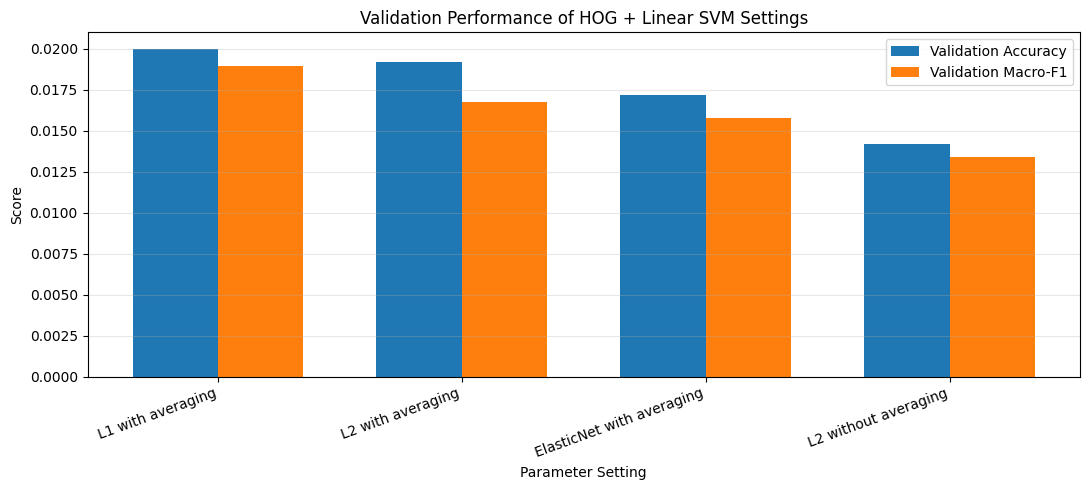

Figure saved to:
/content/drive/MyDrive/COMP9517_Group_Assignment/results/tuning_result/parameter_comparison.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Sort models by validation Macro-F1.
plot_df = parameter_results_df.sort_values(
    by="validation_macro_f1",
    ascending=False
).reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(11, 5))

plt.bar(
    x - width / 2,
    plot_df["validation_accuracy"],
    width,
    label="Validation Accuracy"
)

plt.bar(
    x + width / 2,
    plot_df["validation_macro_f1"],
    width,
    label="Validation Macro-F1"
)

plt.xticks(
    x,
    plot_df["setting"],
    rotation=20,
    ha="right"
)

plt.xlabel("Parameter Setting")
plt.ylabel("Score")
plt.title("Validation Performance of HOG + Linear SVM Settings")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the figure permanently to Google Drive.
tuning_result_dir = Path(
    "/content/drive/MyDrive/COMP9517_Group_Assignment/"
    "results/tuning_result"
)

tuning_result_dir.mkdir(parents=True, exist_ok=True)

figure_file = tuning_result_dir / "parameter_comparison.png"

plt.savefig(
    figure_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_file)